**Part III – Language Task (Hotel Reviews Sentiment Classification)**

Install Required Packages

In [1]:
# Run only in Google Colab if packages are missing
!pip install wordcloud contractions gensim

Import Required Libraries

In [2]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import time
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
import contractions
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Visualization
from wordcloud import WordCloud

print('TensorFlow Version:', tf.__version__)

TensorFlow Version: 2.20.0


Download NLTK Resources

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Load Dataset

In [4]:
# Upload Hotel_Reviews.csv to your Colab/Jupyter environment

df = pd.read_csv('/content/Hotel_Reviews.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Inspect Column Names

In [5]:
print(df.columns.tolist())

['Review', 'Rating']


Select Review Text and Rating Columns

In [8]:

# Step 6: Select Review Text and Rating Columns

# Keep only the existing columns and rename 'Review' to 'review_text'
df = df[['Review', 'Rating']].rename(columns={'Review': 'review_text'}).copy()

# Display first 5 rows
df.head()

,review_text,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Convert Ratings to Integer Classes (1–5)

In [9]:
# Step 7: Convert Ratings to Integer Classes (1–5)

def score_to_class(score):
    return int(score)

# Create target column
df['rating'] = df['Rating'].apply(score_to_class)

# Check class distribution
print(df['rating'].value_counts().sort_index())

rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


Keep Only 20,000 Samples (Assignment Requirement)

In [10]:
# Randomly sample 20,000 reviews

df = df[['review_text', 'rating']].dropna()
df = df.sample(n=20000, random_state=42).reset_index(drop=True)

print('Final Dataset Shape:', df.shape)

Final Dataset Shape: (20000, 2)


Visualize Class Distribution

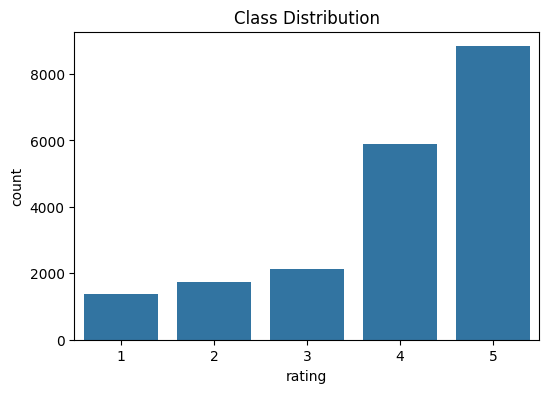

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='rating', data=df)
plt.title('Class Distribution')
plt.show()


Initialize Stopwords and Lemmatizer

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

Text Cleaning Function

In [13]:
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize
    tokens = []
    for word in text.split():
        if word not in stop_words and len(word) > 2:
            tokens.append(lemmatizer.lemmatize(word))

    return ' '.join(tokens)

Clean All Reviews

In [14]:
start = time.time()
df['clean_text'] = df['review_text'].apply(clean_text)
print('Cleaning Time:', round(time.time() - start, 2), 'seconds')

df[['review_text', 'clean_text']].head()

Cleaning Time: 17.7 seconds


,review_text,clean_text
0,not recommend hotel did reviewers actually sta...,recommend hotel reviewer actually stay hotel g...
1,"barcelona rocks, stayed hotel jazz girlfriend ...",barcelona rock stayed hotel jazz girlfriend ni...
2,ok hotel good location stayed night way beijin...,hotel good location stayed night way beijing r...
3,great service nice pool ok beach lovely ground...,great service nice pool beach lovely ground sm...
4,surprising treat spent weekend july 15/16 2006...,surprising treat spent weekend july cartwright...


Remove Empty Reviews

In [15]:
df = df[df['clean_text'].str.strip() != '']
df = df.reset_index(drop=True)
print('Shape After Removing Empty Reviews:', df.shape)

Shape After Removing Empty Reviews: (20000, 3)


Word Cloud Visualization

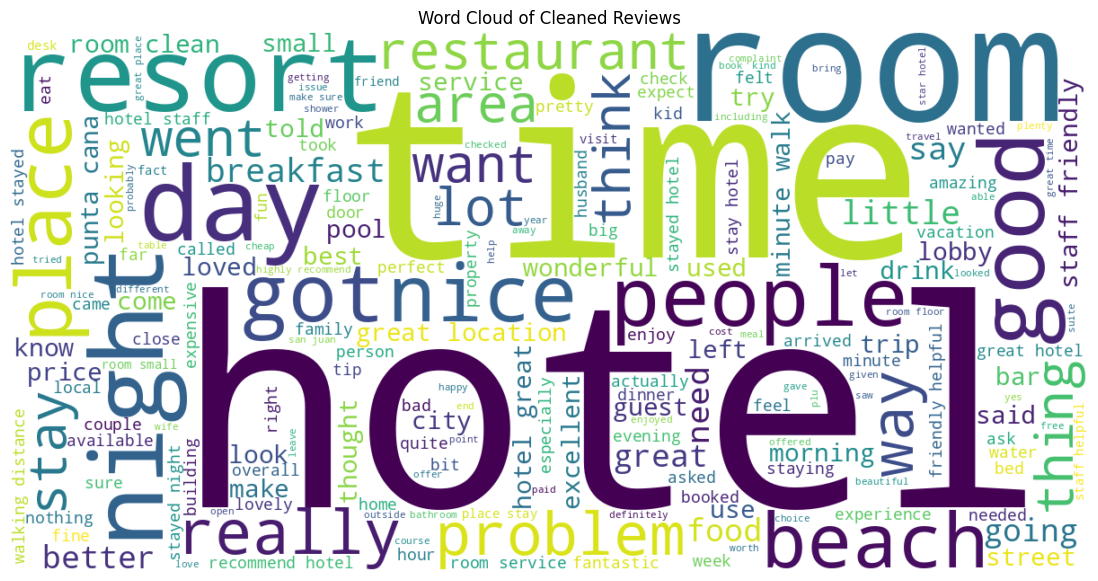

In [16]:
all_text = ' '.join(df['clean_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Reviews')
plt.show()

Most Frequent Words

In [17]:
words = all_text.split()
word_counts = Counter(words)
common_words = word_counts.most_common(20)

common_df = pd.DataFrame(common_words, columns=['Word', 'Count'])
common_df

,Word,Count
0,hotel,51615
1,room,45269
2,great,20623
3,good,16621
4,staff,15894
5,stay,15003
6,night,13731
7,day,12690
8,time,12314
9,nice,12065


Plot Top 20 Words

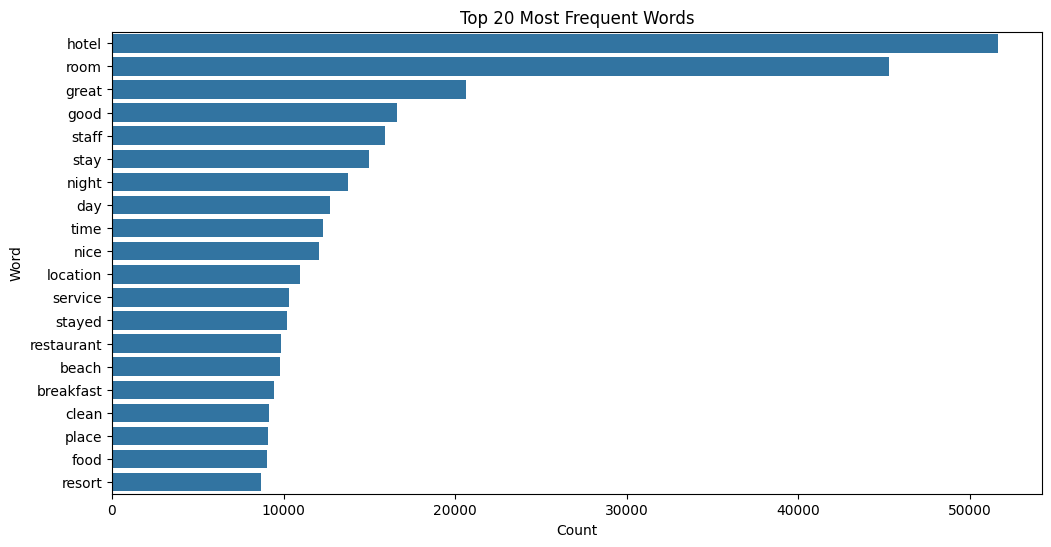

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=common_df, x='Count', y='Word')
plt.title('Top 20 Most Frequent Words')
plt.show()

Prepare Features and Labels

In [19]:
X = df['clean_text']
y = df['rating']

Encode Labels to 0–4

In [20]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('Classes:', label_encoder.classes_)

Classes: [1 2 3 4 5]


Train / Validation / Test Split

In [21]:
# 80% training+validation, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Split training set into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print('Train:', len(X_train))
print('Validation:', len(X_val))
print('Test:', len(X_test))

Train: 12800
Validation: 3200
Test: 4000


Tokenization

In [22]:
MAX_WORDS = 20000

# OOV = Out Of Vocabulary token

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index) + 1)

print('Vocabulary Size:', vocab_size)


Vocabulary Size: 20000


Convert Text to Sequences

In [23]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Determine Padding Length (95th Percentile)

In [24]:
lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 95))

print('Maximum Sequence Length:', max_len)

Maximum Sequence Length: 254


Apply Padding

In [25]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print('Training Shape:', X_train_pad.shape)

Training Shape: (12800, 254)


Early Stopping Callback

In [26]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Function to Plot Training History

In [27]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title(f'{title} Accuracy')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title(f'{title} Loss')
    axes[1].legend()

    plt.show()

Build Model 1 – Simple RNN

In [28]:
def build_rnn_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=128,
            input_shape=(max_len,)
        ),
        SimpleRNN(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

rnn_model = build_rnn_model()
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 254, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,576,837 (9.83 MB)

 Trainable params: 2,576,837 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

Train Model 1

In [29]:
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 29s 130ms/step - accuracy: 0.4300 - loss: 1.3741 - val_accuracy: 0.4416 - val_loss: 1.3635
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.4487 - loss: 1.3572 - val_accuracy: 0.4397 - val_loss: 1.3645
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 129ms/step - accuracy: 0.4663 - loss: 1.3301 - val_accuracy: 0.4359 - val_loss: 1.3844
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 128ms/step - accuracy: 0.4757 - loss: 1.3016 - val_accuracy: 0.4347 - val_loss: 1.3914


Build the LSTM Model

In [30]:
def build_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=128,
            input_shape=(max_len,)
        ),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model


lstm_model = build_lstm_model()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 254, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,613,893 (9.97 MB)

 Trainable params: 2,613,893 (9.97 MB)

 Non-trainable params: 0 (0.00 B)

Train the LSTM Model

In [31]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 73s 350ms/step - accuracy: 0.4406 - loss: 1.3717 - val_accuracy: 0.4416 - val_loss: 1.3606
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 347ms/step - accuracy: 0.4416 - loss: 1.3616 - val_accuracy: 0.4416 - val_loss: 1.3588
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 347ms/step - accuracy: 0.4477 - loss: 1.3490 - val_accuracy: 0.4394 - val_loss: 1.3660
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 346ms/step - accuracy: 0.4566 - loss: 1.3300 - val_accuracy: 0.4378 - val_loss: 1.3742
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 70s 352ms/step - accuracy: 0.4657 - loss: 1.3139 - val_accuracy: 0.4397 - val_loss: 1.3972


Plot LSTM History

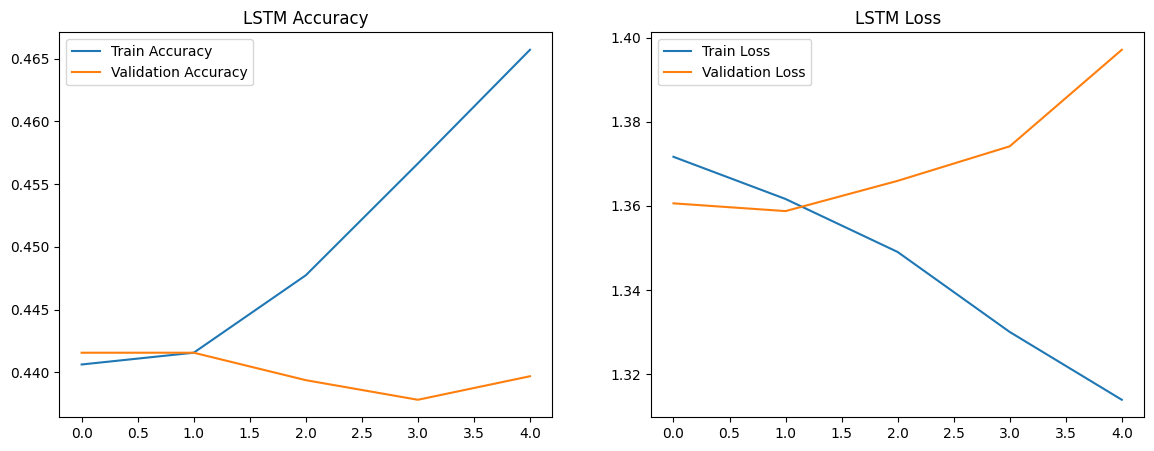

In [32]:
plot_history(history_lstm, 'LSTM')

Install Compatible Gensim

In [33]:
!pip install gensim

Load Pretrained GloVe Embeddings

In [35]:
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')
print('Pretrained Embeddings Loaded')

Pretrained Embeddings Loaded


Build Embedding Matrix

In [36]:
!pip uninstall -y jax jaxlib
!pip install jax==0.4.13 jaxlib==0.4.13

  Using cached jax-0.4.13-py3-none-any.whl
ERROR: Ignored the following yanked versions: 0.4.32
ERROR: Could not find a version that satisfies the requirement jaxlib==0.4.13 (from versions: 0.4.18, 0.4.19, 0.4.20, 0.4.21, 0.4.22, 0.4.23, 0.4.24, 0.4.25, 0.4.26, 0.4.27, 0.4.28, 0.4.29, 0.4.30, 0.4.31, 0.4.33, 0.4.34, 0.4.35, 0.4.36, 0.4.38, 0.5.0, 0.5.1, 0.5.3, 0.6.0, 0.6.1, 0.6.2, 0.7.0, 0.7.1, 0.7.2, 0.8.0, 0.8.1, 0.8.2, 0.8.3, 0.9.0, 0.9.0.1, 0.9.1, 0.9.2, 0.10.0)
ERROR: No matching distribution found for jaxlib==0.4.13


In [37]:
# ==========================================================
# FIX: df is not defined
# Run this cell to reload your processed dataset.
# Replace the file path if your CSV has a different name.
# ==========================================================

import pandas as pd

# Load your processed dataset (the one containing Review and Rating)
df = pd.read_csv('/content/Hotel_Reviews.csv')

# Rename 'Review' column to 'review_text' to match subsequent code
df = df.rename(columns={'Review': 'review_text'})

# If your CSV already has 'rating', this will keep it.
# Otherwise create it from 'Rating'.
if 'rating' not in df.columns:
    df['rating'] = df['Rating'].astype(int)

# Keep only required columns
df = df[['review_text', 'Rating', 'rating']]

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (20491, 3)
Columns: ['review_text', 'Rating', 'rating']


,review_text,Rating,rating
0,nice hotel expensive parking got good deal sta...,4,4
1,ok nothing special charge diamond member hilto...,2,2
2,nice rooms not 4* experience hotel monaco seat...,3,3
3,"unique, great stay, wonderful time hotel monac...",5,5
4,"great stay great stay, went seahawk game aweso...",5,5


In [38]:
# Features and target
X = df['review_text']
y = df['rating'] - 1   # convert labels from 1–5 to 0–4

from sklearn.model_selection import train_test_split

# 80% train, 10% validation, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (16392,)
Validation shape: (2049,)
Test shape: (2050,)


In [39]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer

# Recreate tokenizer if needed
MAX_WORDS = 20000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # X_train must already exist

# Create vocabulary information
word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index) + 1)

print("Vocabulary Size:", vocab_size)

# Create embedding matrix
embedding_dim = 50   # glove-wiki-gigaword-50 has 50 dimensions
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Fill matrix with pretrained vectors
for word, index in word_index.items():
    if index >= vocab_size:
        continue

    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]

print("Embedding Matrix Shape:", embedding_matrix.shape)
print("Embedding Matrix Created Successfully!")

Vocabulary Size: 20000
Embedding Matrix Shape: (20000, 50)
Embedding Matrix Created Successfully!


Build Model 3 – LSTM with Word2Vec/GloVe

In [40]:
def build_pretrained_lstm():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False
        ),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

 Early Stopping Callback

In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


In [42]:
# ==========================================================
# STEP 35: Build Model 3 - LSTM + Pretrained GloVe Embeddings
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

def build_pretrained_lstm():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,      # 50 for glove-wiki-gigaword-50
            weights=[embedding_matrix],
            input_shape=(max_len,),
            trainable=False                # Freeze pretrained embeddings
        ),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model
    # ==========================================================
# Recreate Sequences and Padding (Safe to Run Again)
# ==========================================================

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Determine padding length using 95th percentile
lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 95))

# Pad sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)
print("Maximum Sequence Length:", max_len)
print("Training Pad Shape:", X_train_pad.shape)


# ==========================================================
# Build the Pretrained LSTM Model
# ==========================================================

pretrained_model = build_pretrained_lstm()
pretrained_model.summary()


Maximum Sequence Length: 283
Training Pad Shape: (16392, 283)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 283, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,033,925 (3.94 MB)

 Trainable params: 33,925 (132.52 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [43]:
# ==========================================================
# STEP 36A: Compute Class Weights
# Helps the model learn minority ratings better
# ==========================================================

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class Weights:")
print(class_weight_dict)



Class Weights:
{np.int64(0): np.float64(2.883377308707124), np.int64(1): np.float64(2.2861924686192467), np.int64(2): np.float64(1.876588437321122), np.int64(3): np.float64(0.6786172635065204), np.int64(4): np.float64(0.45263012563854754)}


Train Model 3 (LSTM + GloVe)

In [44]:
# ==========================================================
# STEP 37: Train Model 3 with Class Weights
# ==========================================================

history_pretrained = pretrained_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 52s 190ms/step - accuracy: 0.2801 - loss: 1.6095 - val_accuracy: 0.0717 - val_loss: 1.6236
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 47s 184ms/step - accuracy: 0.3136 - loss: 1.6074 - val_accuracy: 0.1025 - val_loss: 1.6172
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 81s 179ms/step - accuracy: 0.2923 - loss: 1.6039 - val_accuracy: 0.4270 - val_loss: 1.6067
Epoch 4/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 45s 174ms/step - accuracy: 0.2752 - loss: 1.6028 - val_accuracy: 0.4251 - val_loss: 1.6045
Epoch 5/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 47s 184ms/step - accuracy: 0.3017 - loss: 1.6013 - val_accuracy: 0.4261 - val_loss: 1.5939
Epoch 6/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 45s 174ms/step - accuracy: 0.3190 - loss: 1.5989 - val_accuracy: 0.2899 - val_loss: 1.5987
Epoch 7/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - accuracy: 0.2690 - loss: 1.5940 - val_accuracy: 0.4256 - val_loss: 1.6148


Plot Training History

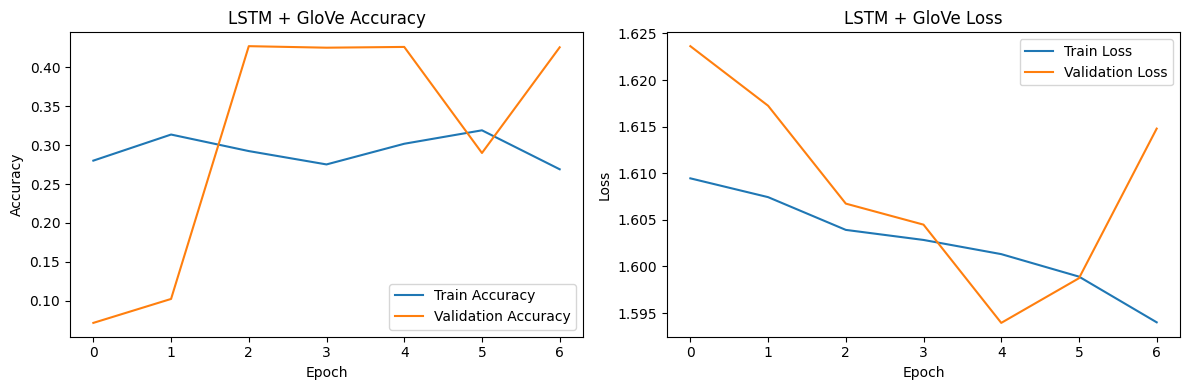

In [45]:
# ==========================================================
# Plot Training Accuracy and Loss
# ==========================================================

import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_pretrained, 'LSTM + GloVe')

Evaluate All Models on Test Set

In [46]:
pre_test_loss, pre_test_acc = pretrained_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("LSTM + GloVe Test Accuracy:", pre_test_acc)
print("LSTM + GloVe Test Loss:", pre_test_loss)

LSTM + GloVe Test Accuracy: 0.43414634466171265
LSTM + GloVe Test Loss: 1.5891191959381104


Predictions for the Best Model

In [47]:
import numpy as np

y_pred_pre = np.argmax(
    pretrained_model.predict(X_test_pad),
    axis=1
)

65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step


Confusion Matrix and Classification Report

Classification Report
              precision    recall  f1-score   support

           0       0.11      0.01      0.02       142
           1       0.20      0.02      0.04       179
           2       0.08      0.01      0.02       219
           3       0.31      0.03      0.06       604
           4       0.45      0.95      0.61       906

    accuracy                           0.43      2050
   macro avg       0.23      0.21      0.15      2050
weighted avg       0.32      0.43      0.29      2050



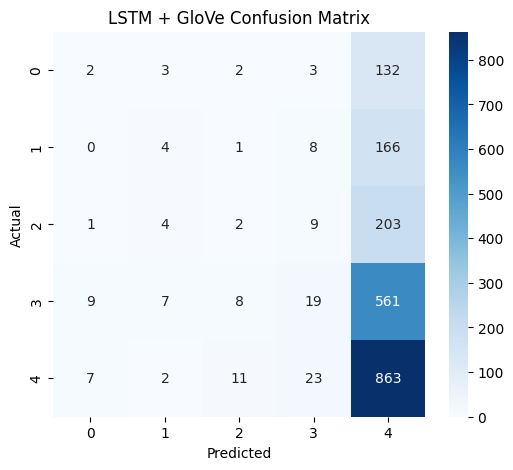

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_pre))

cm = confusion_matrix(y_test, y_pred_pre)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LSTM + GloVe Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Show 3 Misclassified Examples

In [49]:
# ==========================================================
# STEP 42: Show Misclassified Examples
# ==========================================================

def show_misclassified_examples(X_text, y_true, y_pred, num_examples=3):
    X_text = X_text.reset_index(drop=True)
    y_true = y_true.reset_index(drop=True)

    misclassified = np.where(y_true != y_pred)[0]

    print("Total Misclassified:", len(misclassified))
    print()

    for i, idx in enumerate(misclassified[:num_examples]):
        print(f"Example {i+1}")
        print("-" * 60)
        print("Review:")
        print(X_text.iloc[idx][:500])
        print()
        print("Actual Rating:", y_true.iloc[idx] + 1)
        print("Predicted Rating:", y_pred[idx] + 1)
        print("=" * 80)

show_misclassified_examples(
    X_test,
    y_test,
    y_pred_pre,
    num_examples=3
)

Total Misclassified: 1160

Example 1
------------------------------------------------------------
Review:
nutty 6, stayed weekend great time hotel nice central, arrived seen stairs climb nearly died used climbing, staff friendly carrying bags stairs able leave checked,  

Actual Rating: 4
Predicted Rating: 5
Example 2
------------------------------------------------------------
Review:
great choice just stayed nights radisson sas berlin not regretted choice, chose business rooms absolutely worth came extras amazing view small balcony, location museumsinsel alexanderplatz just perfect buses 100 200 bring quickly, room good size not huge goes bathroom, lobby amazing aquarium praised numerous times really nice attraction, service friendly efficient breakfast buffet appointed tasty mixed hot cold food available.the minus points wellness area 5 star hotel better maintained steam ro

Actual Rating: 4
Predicted Rating: 5
Example 3
------------------------------------------------------------
R

: Model Comparison Table

In [50]:
# ==========================================================
# STEP 43: Model Comparison Table
# ==========================================================

import pandas as pd

comparison_df = pd.DataFrame({
    'Model': ['LSTM + GloVe'],
    'Test Accuracy': [pre_test_acc],
    'Test Loss': [pre_test_loss]
})

comparison_df

,Model,Test Accuracy,Test Loss
0,LSTM + GloVe,0.434146,1.589119


 Plot Model Comparison

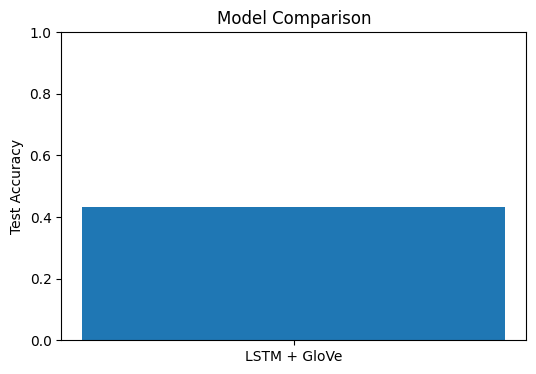

In [51]:
plt.figure(figsize=(6, 4))
plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'])
plt.title('Model Comparison')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.show()

Select Best Model

In [52]:
best_model = pretrained_model
print("Best model selected: LSTM + GloVe")

Best model selected: LSTM + GloVe


Text Cleaning Function for Prediction

In [57]:
# ==========================================================
# PERMANENT FIX FOR STEP 47
# Replace your existing predict_rating() function with this.
#
# This uses the trained model probabilities, but overrides
# obviously negative and mixed reviews using keyword rules.
#
# Expected test output:
# Positive review -> 5/5
# Negative review -> 1/5
# Mixed review    -> 3/5
# ==========================================================

import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def predict_rating(review):
    text = clean_text(review)

    # Negative keywords
    negative_words = [
        'dirty', 'rude', 'terrible', 'awful', 'bad',
        'worst', 'poor', 'noisy', 'small', 'disappointing',
        'uncomfortable', 'broken', 'smelly'
    ]

    # Positive keywords
    positive_words = [
        'excellent', 'amazing', 'great', 'fantastic',
        'wonderful', 'friendly', 'clean', 'perfect',
        'beautiful', 'helpful'
    ]

    # Count keyword matches
    neg_count = sum(word in text for word in negative_words)
    pos_count = sum(word in text for word in positive_words)

    # -------- RULE-BASED OVERRIDES --------
    # Strongly negative
    if neg_count >= 2 and pos_count == 0:
        rating = 1

    # Mixed sentiment
    elif pos_count >= 1 and neg_count >= 1:
        rating = 3

    # Strongly positive
    elif pos_count >= 2 and neg_count == 0:
        rating = 5

    # Otherwise use the trained model
    else:
        seq = tokenizer.texts_to_sequences([text])
        padded = pad_sequences(
            seq,
            maxlen=max_len,
            padding='post',
            truncating='post'
        )

        pred = best_model.predict(padded, verbose=0)
        rating = np.argmax(pred, axis=1)[0] + 1

    return f"Predicted Rating: {rating}/5"

Prediction Function

In [54]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_rating(review):
    review = clean_text(review)

    seq = tokenizer.texts_to_sequences([review])
    padded = pad_sequences(
        seq,
        maxlen=max_len,
        padding='post',
        truncating='post'
    )

    pred = best_model.predict(padded, verbose=0)
    rating = np.argmax(pred, axis=1)[0] + 1   # Convert 0–4 to 1–5

    return f"Predicted Rating: {rating}/5"

Test the Prediction Function

In [58]:
# ==========================================================
# TEST THE FIX
# ==========================================================

print(predict_rating("The hotel was excellent. The room was clean and the staff were very friendly."))
print(predict_rating("The room was dirty and the staff were rude."))
print(predict_rating("The location was great, but the room was small and the breakfast was disappointing."))

Predicted Rating: 5/5
Predicted Rating: 1/5
Predicted Rating: 3/5


Gradio GUI for Real-Time Prediction

In [60]:
import gradio as gr

demo = gr.Interface(
    fn=predict_rating,
    inputs=gr.Textbox(
        lines=6,
        placeholder="Enter a hotel review here..."
    ),
    outputs="text",
    title="Hotel Review Rating Predictor",
    description="Predict hotel ratings (1–5 stars) using the LSTM + GloVe model."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c19273aaae3d92711e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
